# Agentic RAG @ `LangGraph`

In [1]:
# Importing necessary libraries

from typing import Annotated, Literal, Sequence, TypedDict
from langchain_classic import hub
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
from langgraph.prebuilt import tools_condition
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_classic.tools.retriever import create_retriever_tool
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode

/Users/soubhiksinha/GitHub/Agentic-RAG-LangGraph/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
# Loading Hugging Face Embedings model

from langchain_huggingface import HuggingFaceEmbeddings

In [3]:
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 21714.67it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
# Loading LLM Model

from langchain_groq import ChatGroq

In [5]:
llm=ChatGroq(model_name="llama-3.1-8b-instant")

In [6]:
llm.invoke("Hi, How are you doing?")

AIMessage(content="I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or tasks you may have. How about you? Is there something I can assist you with today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 42, 'total_tokens': 104, 'completion_time': 0.066849892, 'completion_tokens_details': None, 'prompt_time': 0.002961496, 'prompt_tokens_details': None, 'queue_time': 0.006027066, 'total_time': 0.069811388}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019db613-de50-7380-be33-3efb07e7b3a2-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 62, 'total_tokens': 104})

<br>

# Fetching Data from Internet

In [7]:
urls = [
  "https://lilianweng.github.io/posts/2023-06-23-agent/",
  "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
]

In [8]:
# Loading the data

docs = [WebBaseLoader(url).load() for url in urls]

In [9]:
docs

[[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final res

In [10]:
docs[0][0].metadata

{'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/',
 'title': "LLM Powered Autonomous Agents | Lil'Log",
 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final results.\n\n\nMemory\

In [11]:
docs[1][0].metadata

{'source': 'https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/',
 'title': "Prompt Engineering | Lil'Log",
 'description': 'Prompt Engineering, also known as In-Context Prompting, refers to methods for how to communicate with LLM to steer its behavior for desired outcomes without updating the model weights. It is an empirical science and the effect of prompt engineering methods can vary a lot among models, thus requiring heavy experimentation and heuristics.\nThis post only focuses on prompt engineering for autoregressive language models, so nothing with Cloze tests, image generation or multimodality models. At its core, the goal of prompt engineering is about alignment and model steerability. Check my previous post on controllable text generation.',
 'language': 'en'}

In [12]:
# Iterating over the docs
docs_list = [item for sublist in docs for item in sublist]

In [13]:
docs_list

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [14]:
# Chunking the text

textSplitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(chunk_size=100, chunk_overlap=5)

In [15]:
# Passing data to the above text splitter

doc_splits = textSplitter.split_documents(docs_list)

In [16]:
doc_splits

[Document(metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, thereby improving the quality of final resu

In [17]:
# Initializing Vector DB

vectorStore=Chroma.from_documents(
  documents=doc_splits,
  collection_name="rag-chroma", # Index
  embedding=embeddings
)

In [18]:
retriever = vectorStore.as_retriever()

In [19]:
retriever_tool = create_retriever_tool(
  retriever,
  "blog_search",
  "Search and return information about Lilian Weng blog posts on LLM agents, prompt engineering, and agentic AI"  # Tool Description
)

In [20]:
# Creating tool list

tools = [retriever_tool]

<br>

# Creating Functions
`Imagine Functions as NODES`

In [21]:
class AgentState(TypedDict):
  messages: Annotated[Sequence[BaseMessage], add_messages] # We can keep multiple messages in a single list

In [22]:
class grade(BaseModel):
  binary_score: str  = Field(description="Relevance score 'yes' or 'no'") # For grading whether the doc is relevant or not

In [23]:
def ai_assistant(state: AgentState):
  print("---CALL AGENT---")
  messages = state['messages'] # Taking message(s)
  llm_with_tool = llm.bind_tools(tools) # Binding tools with the LLM
  response = llm_with_tool.invoke(messages) # Giving message(s) (Input) to the LLM
  return {"messages": [response]} # Obtaining response

In [24]:
retrieve=ToolNode([retriever_tool])

In [25]:
def generate(state: AgentState):
  print("---GENERATE---")
  messages = state["messages"]
  question = messages[0].content
  last_message = messages[-1]
  docs = last_message.content

  prompt = hub.pull("rlm/rag-prompt")

  rag_chain = prompt | llm | StrOutputParser()

  response = rag_chain.invoke({"context": docs, "question": question})
  return {"messages": [response]}

In [26]:
def grade_documents(state:AgentState):
  llm_with_structure_op = llm.with_structured_output(grade)

  prompt = PromptTemplate(
    template = """You are a grader assessing relevance of a retrieved dcoument to a user question. \n
    Here is the retrieved documents: \n\n {context} \n\n
    Here is the user question: {question} \n
    If the document contains keyword(s) or semantic meaning related to the user question, grade it and
    give binary score 'yes' or 'no' score to indicate whether the document is relevant to teh question or not.""",
    input_variables = ["context", "question"]
  )
  chain = prompt | llm_with_structure_op

  messages = state["messages"]
  last_message = messages[-1]

  question = messages[0].content
  docs = last_message.content

  scored_result = chain.invoke({"question": question, "context": docs})

  score = scored_result.binary_score

  if score == "yes":
    print("---DECISION: DOCS RELEVANT---")
    return "generator"
  else:
    print("---DECISION: DOCS NOT RELEVANT---")
    return "rewriter"
  

In [27]:
def rewrite(state: AgentState):
  print("---TRANSFORM QUERY---")
  messages = state["messages"]
  question = messages[0]

  msg =[
    HumanMessage(
      content=f"""\n
      Look at the input and try to reason about the underlying semantic intent / meaning. \n
      Here is the initial question:
      \n ------- \n
      {question}
      \n ------- \n
      Formulate an improved question: """, 
    )
  ]

  # Grader
  response = llm.invoke(msg)
  return {"messages": [response]}

<br>

# Creating Workflow

In [28]:
# Creating workflow + Adding nodes

workflow = StateGraph(AgentState)
workflow.add_node("ai_assistant", ai_assistant)
workflow.add_node("retriever", retrieve)
workflow.add_node("rewriter", rewrite)
workflow.add_node("generator", generate)

In [29]:
# Adding edges + Conditional edges

workflow.add_edge(START, "ai_assistant")
workflow.add_conditional_edges(
  "ai_assistant", 
  tools_condition, 
  {
    "tools": "retriever",
    END: END,
  })

In [30]:
workflow.add_conditional_edges(
  "retriever",
  grade_documents,
  {"rewriter": "rewriter", "generator": "generator"}
)

In [31]:
workflow.add_edge("generator", END)

In [32]:
workflow.add_edge("rewriter", "ai_assistant")

In [33]:
# Compiling workflow
app=workflow.compile()

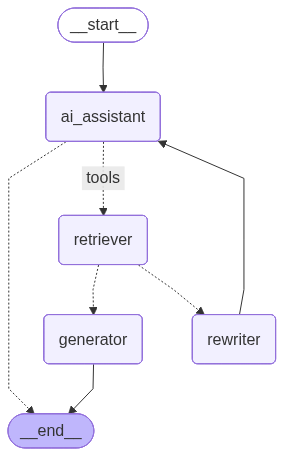

In [34]:
# Let's visualize the application (workflow)

from IPython.display import Image, display

try:
  display(Image(app.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependenices and is optional
    pass

<br>

# Application (Workflow) Invoke

In [37]:
print("llm:", llm)
print("tools:", tools)
print("tool names:", [t.name for t in tools])

llm_with_tool = llm.bind_tools(tools)
print("bound tool names:", [t.name for t in tools])

llm: output_version=None profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True} client=<groq.resources.chat.completions.Completions object at 0x13749ec90> async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x137521f10> model_name='llama-3.1-8b-instant' model_kwargs={} groq_api_key=SecretStr('**********') groq_api_base=None groq_proxy=None
tools: [StructuredTool(name='blog_search', description='Search and return information about Lilian Weng blog posts on LLM agents, prompt engineering, and agentic AI', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x1465ac2c0>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x1465ac360>)]
tool names: ['blog_search']
bound tool names: ['blog_search

In [38]:
# Testing whether tools are eing called or NOT

response = app.invoke({"messages": ["What is a Autonomous Agent?"]})

for msg in response["messages"]:
    print(type(msg).__name__)
    print(msg)
    print("-" * 80)

---CALL AGENT---
HumanMessage
content='What is a Autonomous Agent?' additional_kwargs={} response_metadata={} id='3e593e4d-456c-42eb-91b6-4de559ae7303'
--------------------------------------------------------------------------------
AIMessage
content="The function 'brave_search' does not seem to be specified in the provided options. However, I can provide a definition of an Autonomous Agent.\n\nAn Autonomous Agent is a software system that operates independently, making decisions and taking actions without human intervention. It uses sensors, data, and algorithms to perceive its environment and adapt to it. Autonomous Agents are often used in robotics, artificial intelligence, and other areas where automation is beneficial." additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 87, 'prompt_tokens': 262, 'total_tokens': 349, 'completion_time': 0.336471568, 'completion_tokens_details': None, 'prompt_time': 0.019649278, 'prompt_tokens_details': None, 'queue_time': 0